In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print (pd.__version__)
print (np.__version__)

2.3.3
2.3.5


In [3]:
cft_pdt_data = pd.read_csv("counterfeit_products_balanced_preprocessed_v2.csv")
cft_pdt_data.shape

(5904, 28)

In [4]:
cft_pdt_data.head()

,price,seller_rating,seller_reviews,product_images,description_length,shipping_time_days,spelling_errors,domain_age_days,contact_info_complete,return_policy_clear,...,ip_location_mismatch,seller_country,shipping_origin,brand_suspicious,category_Cosmetics,category_Electronics,category_Fashion,category_Luxury Goods,category_Pharmaceuticals,is_counterfeit
0,277.20,3.500000,890,4,128.0,21.0,0,1440,0,1,...,0,1,6,0,0,0,1,0,0,0
1,89.18,3.978268,1859,3,224.0,31.0,4,206,0,0,...,1,5,5,0,0,1,0,0,0,1
2,168.40,2.700000,1096,2,98.0,10.0,0,1069,1,1,...,0,7,1,1,0,0,1,0,0,1
3,130.98,3.100000,1296,3,255.0,22.0,0,514,1,1,...,0,7,6,0,0,0,0,0,0,0
4,5.00,2.600000,0,2,20.0,32.0,5,5,0,0,...,0,8,9,0,0,0,0,0,1,1


In [5]:
cft_pdt_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5904 entries, 0 to 5903
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   price                     5904 non-null   float64
 1   seller_rating             5904 non-null   float64
 2   seller_reviews            5904 non-null   int64  
 3   product_images            5904 non-null   int64  
 4   description_length        5904 non-null   float64
 5   shipping_time_days        5904 non-null   float64
 6   spelling_errors           5904 non-null   int64  
 7   domain_age_days           5904 non-null   int64  
 8   contact_info_complete     5904 non-null   int64  
 9   return_policy_clear       5904 non-null   int64  
 10  payment_methods_count     5904 non-null   int64  
 11  views                     5904 non-null   int64  
 12  purchases                 5904 non-null   int64  
 13  wishlist_adds             5904 non-null   int64  
 14  certific

In [6]:
cft_pdt_data.isnull().sum()

price                       0
seller_rating               0
seller_reviews              0
product_images              0
description_length          0
shipping_time_days          0
spelling_errors             0
domain_age_days             0
contact_info_complete       0
return_policy_clear         0
payment_methods_count       0
views                       0
purchases                   0
wishlist_adds               0
certification_badges        0
warranty_months             0
bulk_orders                 0
unusual_payment_patterns    0
ip_location_mismatch        0
seller_country              0
shipping_origin             0
brand_suspicious            0
category_Cosmetics          0
category_Electronics        0
category_Fashion            0
category_Luxury Goods       0
category_Pharmaceuticals    0
is_counterfeit              0
dtype: int64

In [7]:
quan=[]
qual=[]
for columnName in cft_pdt_data.columns:
    #print(columnName)
    if(cft_pdt_data[columnName].dtype=='O'):
        #print("qual")
        qual.append(columnName)
    else:
        #print("quan")
        quan.append(columnName)

In [8]:
quan

['price',
 'seller_rating',
 'seller_reviews',
 'product_images',
 'description_length',
 'shipping_time_days',
 'spelling_errors',
 'domain_age_days',
 'contact_info_complete',
 'return_policy_clear',
 'payment_methods_count',
 'views',
 'purchases',
 'wishlist_adds',
 'certification_badges',
 'warranty_months',
 'bulk_orders',
 'unusual_payment_patterns',
 'ip_location_mismatch',
 'seller_country',
 'shipping_origin',
 'brand_suspicious',
 'category_Cosmetics',
 'category_Electronics',
 'category_Fashion',
 'category_Luxury Goods',
 'category_Pharmaceuticals',
 'is_counterfeit']

In [9]:
qual

[]

In [10]:
quan = ['price', 'seller_rating', 'seller_reviews', 'product_images',
        'description_length', 'shipping_time_days', 'spelling_errors',
        'domain_age_days', 'payment_methods_count', 'views', 'purchases',
        'wishlist_adds', 'certification_badges', 'warranty_months']

qual = [col for col in cft_pdt_data.columns if col not in quan]

print("Quantitative:", len(quan))
print("Qualitative:", len(qual))

Quantitative: 14
Qualitative: 14


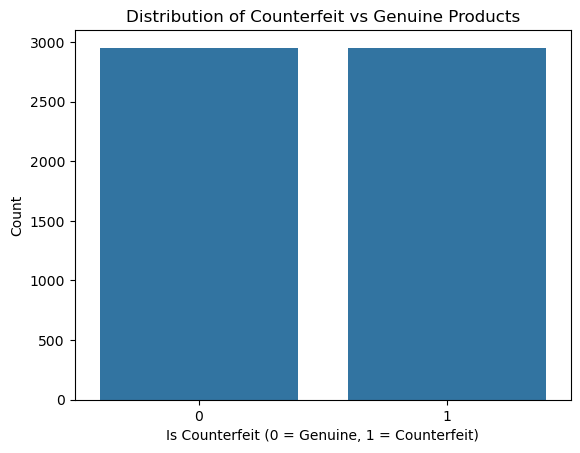

In [11]:
sns.countplot(data=cft_pdt_data, x='is_counterfeit')
plt.title('Distribution of Counterfeit vs Genuine Products')
plt.xlabel('Is Counterfeit (0 = Genuine, 1 = Counterfeit)')
plt.ylabel('Count')
plt.show()

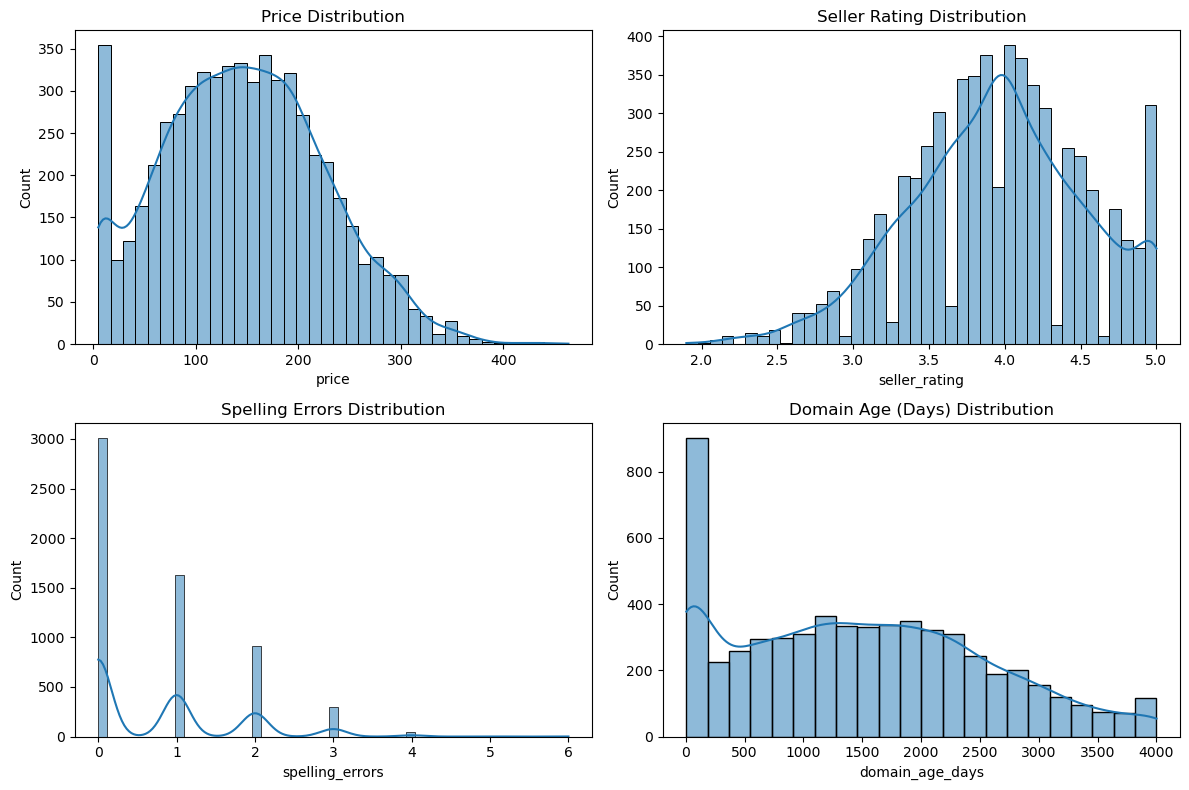

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(data=cft_pdt_data, x='price', kde=True, ax=axes[0,0])
axes[0,0].set_title('Price Distribution')

sns.histplot(data=cft_pdt_data, x='seller_rating', kde=True, ax=axes[0,1])
axes[0,1].set_title('Seller Rating Distribution')

sns.histplot(data=cft_pdt_data, x='spelling_errors', kde=True, ax=axes[1,0])
axes[1,0].set_title('Spelling Errors Distribution')

sns.histplot(data=cft_pdt_data, x='domain_age_days', kde=True, ax=axes[1,1])
axes[1,1].set_title('Domain Age (Days) Distribution')

plt.tight_layout()
plt.show()

In [13]:
cft_pdt_data.corr()

,price,seller_rating,seller_reviews,product_images,description_length,shipping_time_days,spelling_errors,domain_age_days,contact_info_complete,return_policy_clear,...,ip_location_mismatch,seller_country,shipping_origin,brand_suspicious,category_Cosmetics,category_Electronics,category_Fashion,category_Luxury Goods,category_Pharmaceuticals,is_counterfeit
price,1.000000,0.355717,0.295960,0.311707,0.319814,-0.303909,-0.251833,0.312062,0.152830,0.137995,...,-0.089242,0.006772,0.009838,-0.102619,-0.001119,0.020644,0.028017,0.024671,0.019702,-0.251199
seller_rating,0.355717,1.000000,0.333955,0.310259,0.337539,-0.326936,-0.261145,0.326294,0.145674,0.131243,...,-0.090219,0.002809,0.008180,-0.133691,-0.000110,0.021091,0.031337,0.029574,0.015839,-0.271332
seller_reviews,0.295960,0.333955,1.000000,0.261203,0.309347,-0.264239,-0.242533,0.284207,0.145028,0.107058,...,-0.070070,0.028197,0.009838,-0.120788,-0.024455,0.009728,0.013656,0.017862,0.033680,-0.224398
product_images,0.311707,0.310259,0.261203,1.000000,0.298351,-0.263634,-0.205189,0.273340,0.124790,0.118974,...,-0.069911,-0.008021,0.007829,-0.095952,0.001355,0.024383,0.058353,0.022543,0.020312,-0.260716
description_length,0.319814,0.337539,0.309347,0.298351,1.000000,-0.304075,-0.245559,0.299571,0.163680,0.119614,...,-0.084915,-0.000569,-0.014378,-0.113413,-0.005724,0.002750,0.028437,0.012658,0.052648,-0.212510
shipping_time_days,-0.303909,-0.326936,-0.264239,-0.263634,-0.304075,1.000000,0.241079,-0.273179,-0.110514,-0.108391,...,0.089528,-0.016153,-0.008169,0.093801,0.006407,-0.010633,-0.020973,-0.020397,-0.024164,0.223899
spelling_errors,-0.251833,-0.261145,-0.242533,-0.205189,-0.245559,0.241079,1.000000,-0.225085,-0.104158,-0.073991,...,0.088362,0.000418,-0.003435,0.071688,0.026928,-0.000871,-0.004624,-0.006110,0.007996,0.129906
domain_age_days,0.312062,0.326294,0.284207,0.273340,0.299571,-0.273179,-0.225085,1.000000,0.145193,0.095305,...,-0.084553,-0.010169,0.001467,-0.094592,-0.017568,0.027887,0.028942,0.027580,0.009602,-0.217188
contact_info_complete,0.152830,0.145674,0.145028,0.124790,0.163680,-0.110514,-0.104158,0.145193,1.000000,0.074385,...,-0.007738,0.023071,0.008530,-0.047758,0.016134,0.004986,0.023402,0.027659,0.041180,-0.142496
return_policy_clear,0.137995,0.131243,0.107058,0.118974,0.119614,-0.108391,-0.073991,0.095305,0.074385,1.000000,...,-0.017361,-0.011364,0.003300,-0.020937,0.012002,0.032726,0.053947,0.016607,0.032283,-0.149738


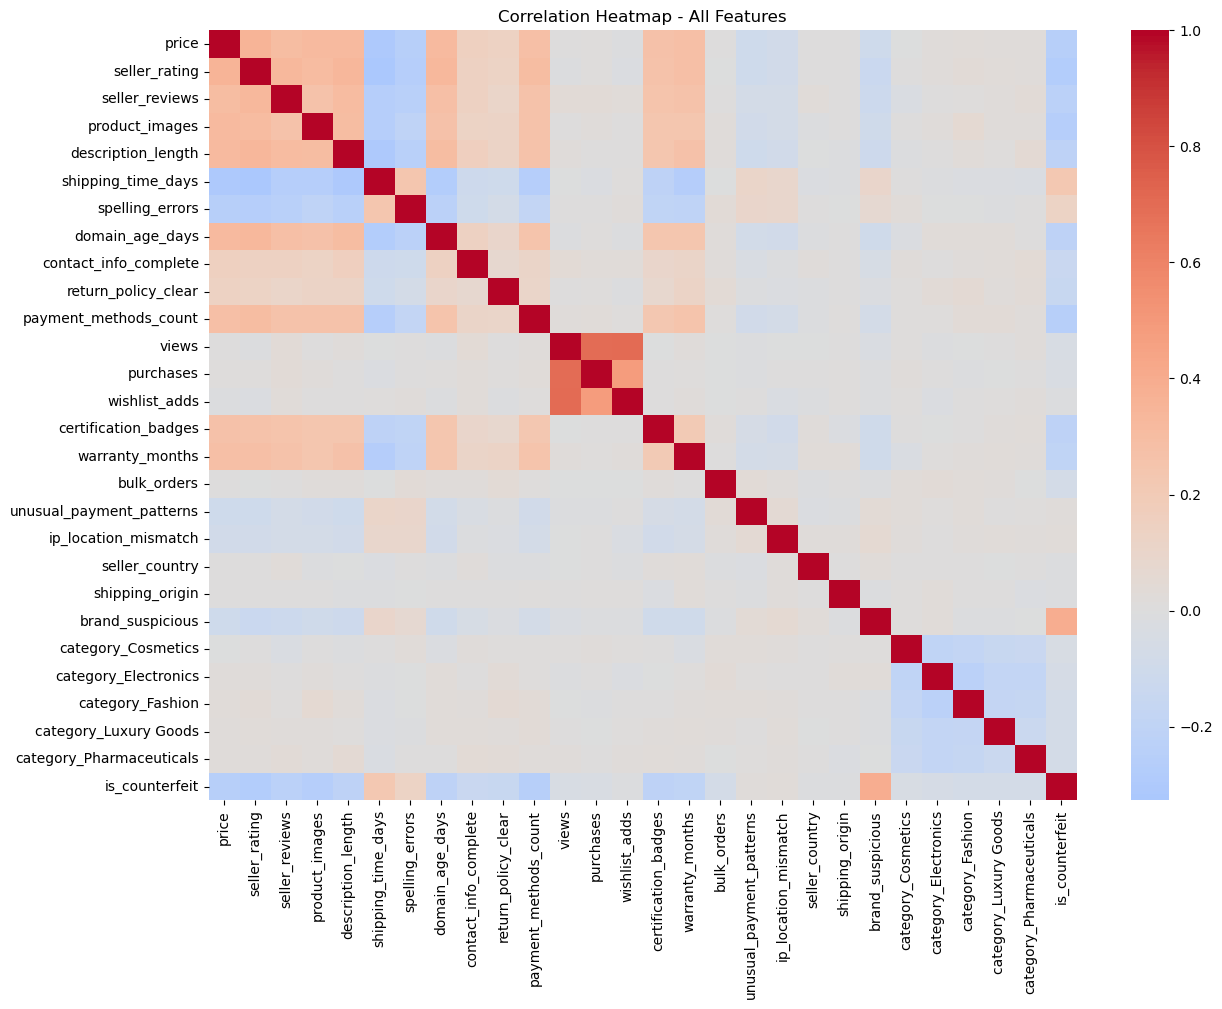

In [14]:
plt.figure(figsize=(14, 10))
sns.heatmap(cft_pdt_data.corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - All Features')
plt.show()

In [15]:
correlation_with_target = cft_pdt_data.corr()['is_counterfeit'].sort_values(ascending=False)
print(correlation_with_target)

is_counterfeit              1.000000
brand_suspicious            0.391450
shipping_time_days          0.223899
spelling_errors             0.129906
ip_location_mismatch        0.028863
unusual_payment_patterns    0.018697
shipping_origin            -0.010506
seller_country             -0.013890
wishlist_adds              -0.014920
purchases                  -0.031662
views                      -0.037191
category_Cosmetics         -0.044261
category_Electronics       -0.057750
category_Fashion           -0.068632
category_Pharmaceuticals   -0.071650
category_Luxury Goods      -0.072903
bulk_orders                -0.075860
contact_info_complete      -0.142496
return_policy_clear        -0.149738
warranty_months            -0.200024
certification_badges       -0.208728
description_length         -0.212510
domain_age_days            -0.217188
seller_reviews             -0.224398
payment_methods_count      -0.251101
price                      -0.251199
product_images             -0.260716
s

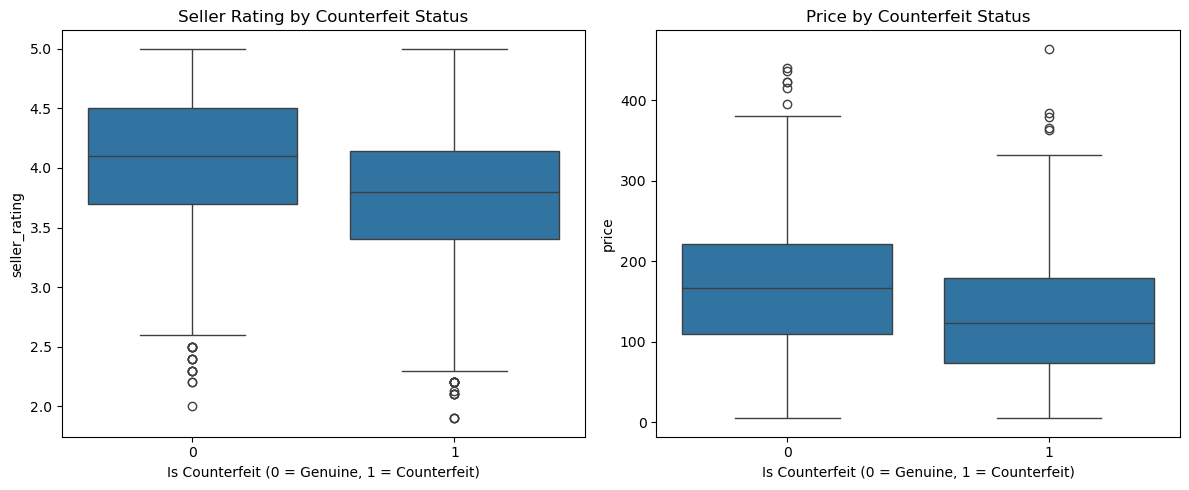

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=cft_pdt_data, x='is_counterfeit', y='seller_rating', ax=axes[0])
axes[0].set_title('Seller Rating by Counterfeit Status')
axes[0].set_xlabel('Is Counterfeit (0 = Genuine, 1 = Counterfeit)')

sns.boxplot(data=cft_pdt_data, x='is_counterfeit', y='price', ax=axes[1])
axes[1].set_title('Price by Counterfeit Status')
axes[1].set_xlabel('Is Counterfeit (0 = Genuine, 1 = Counterfeit)')

plt.tight_layout()
plt.show()